In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uzairsidd/spotify-bdcoe/dataset.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [5]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/uzairsidd/spotify-bdcoe/dataset.csv


In [6]:
import pandas as pd 
df= pd.read_csv("/kaggle/input/datasets/uzairsidd/spotify-bdcoe/dataset.csv")

In [7]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [8]:
df.shape

(114000, 21)

In [9]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [11]:
df.tail()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,...,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,...,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,...,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,...,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,...,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [12]:
df.dtypes

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [13]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


* the datatset contain 114000 records and  21 columns .
* the dataset contains infomration about tracks, artist , album , popularity, genre and secevral other audio characteristics which tell us about the tracks.
* most columns contains complete data with only `artists`, `album_name`, and `track_name` columns having some missing values.
* the datatset contains following type of datatypes: bool(1), float64(9), int64(6), object(5)
* further analysis wil be perfomred to find the missing values and duplicates in more depth.

In [14]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [15]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing

,Missing Values,Percentage
Unnamed: 0,0,0.000000
track_id,0,0.000000
artists,1,0.000877
album_name,1,0.000877
track_name,1,0.000877
popularity,0,0.000000
duration_ms,0,0.000000
explicit,0,0.000000
danceability,0,0.000000
energy,0,0.000000


In [16]:
df[df["artists"].isnull() | 
   df["album_name"].isnull() | 
   df["track_name"].isnull()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


## Univariate Analysis

In this section, we examine the distributions of important numerical features such as popularity, danceability, energy, and song duration.

## Distribution of Song Popularity

Popularity is an important attribute in the Spotify dataset. 
This visualization helps us understand how popularity scores are distributed across the tracks.

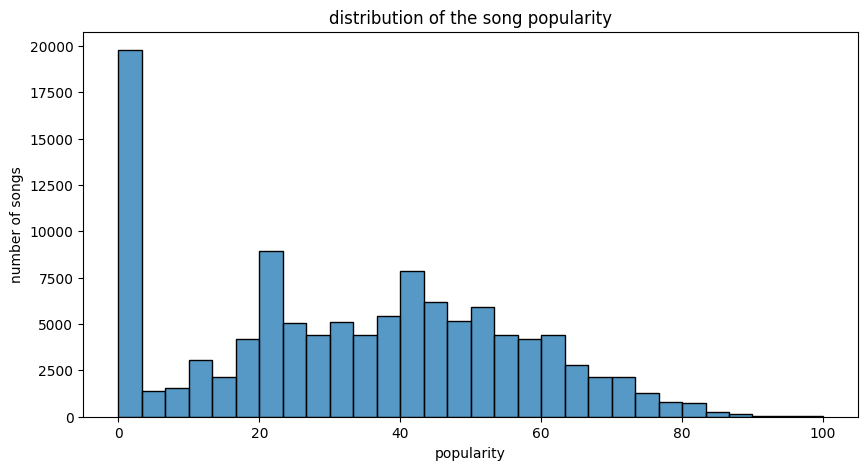

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(data=df,x="popularity",bins=30)

plt.title("distribution of the song popularity")
plt.xlabel("popularity")
plt.ylabel("number of songs")

plt.show()

Observation:

Most songs have a popularity score between approximately 0 and 60. The number of songs decreases as popularity increases, meaning highly popular songs are less common in the dataset.

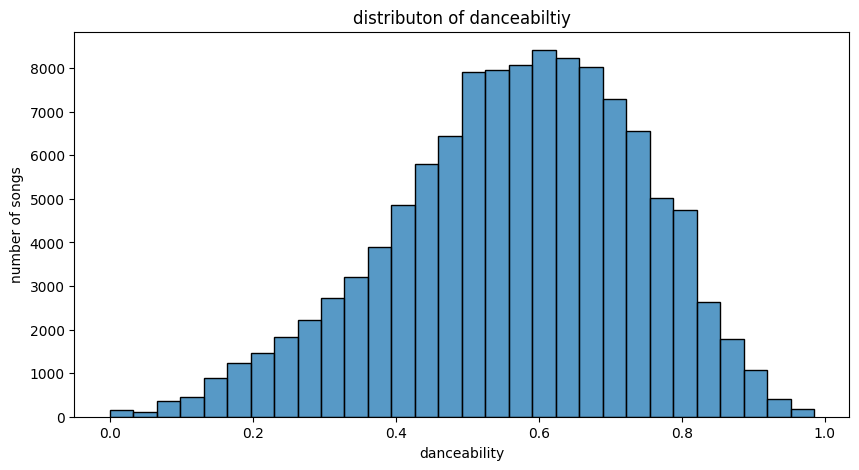

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="danceability", bins=30)
plt.title("distributon of danceabiltiy")
plt.xlabel("danceability")
plt.ylabel("number of songs")

plt.show()

Observation:

Danceability values are spread between 0 and 1, with most songs having moderate to high danceability. The average danceability is approximately 0.57.

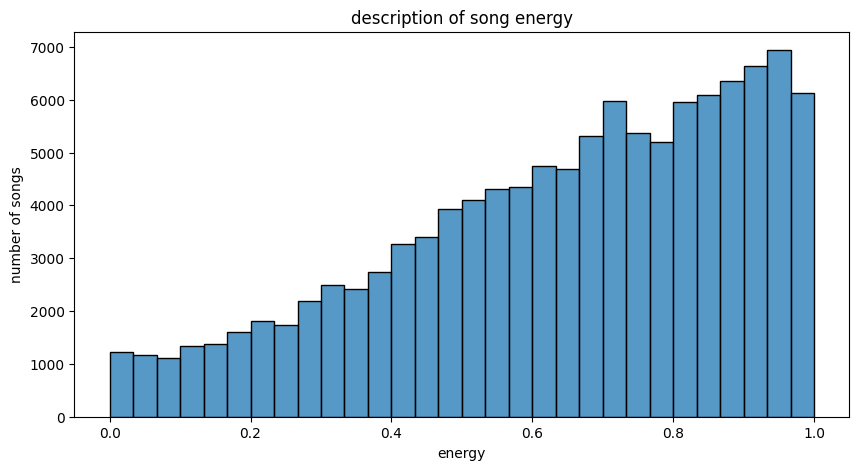

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(data=df,x="energy",bins=30)
plt.title("description of song energy")
plt.xlabel("energy")
plt.ylabel("number of songs")

plt.show()

Observation:

Most songs have moderate to high energy levels. The average energy is approximately 0.64, suggesting that energetic songs are common in the dataset.

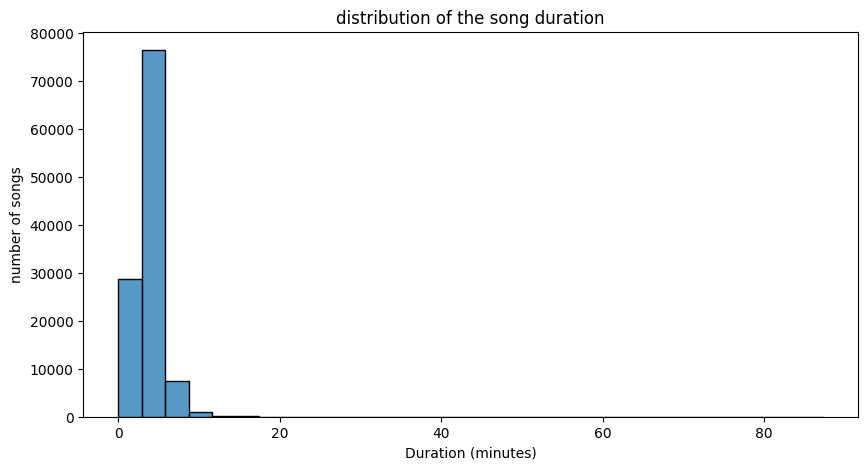

In [36]:
df["duration_min"] = df["duration_ms"] / 60000
plt.figure(figsize=(10,5))
sns.histplot(data=df,x="duration_min",bins=30)
plt.title("distribution of the song duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("number of songs")

plt.show()

Observation:

Most songs have a duration around 2–5 minutes. There are also a few songs with extremely high durations, indicating the presence of potential outliers.

In [23]:
top_artists = df["artists"].value_counts().head(10)
top_artists

artists
The Beatles        279
George Jones       271
Stevie Wonder      236
Linkin Park        224
Ella Fitzgerald    222
Prateek Kuhad      217
Feid               202
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

**Top Artists by Number of Tracks**

This analysis identifies the artists with the highest number of tracks in the dataset.

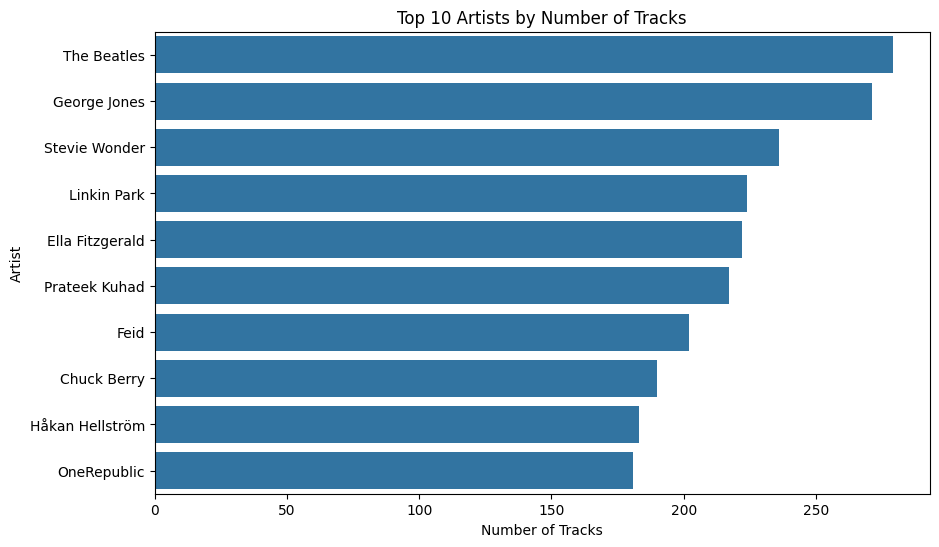

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_artists.values,
    y=top_artists.index
)

plt.title("Top 10 Artists by Number of Tracks")
plt.xlabel("Number of Tracks")
plt.ylabel("Artist")

plt.show()

     **Observation**: The Beatles have the highest number of tracks in the dataset, followed by George Jones and Stevie Wonder. The top 10 artists contribute a relatively large number of tracks compared with other individual artists


**Explicit vs Non-Explicit Songs:
This analysis compares the number of explicit and non-explicit tracks in the dataset.**
**

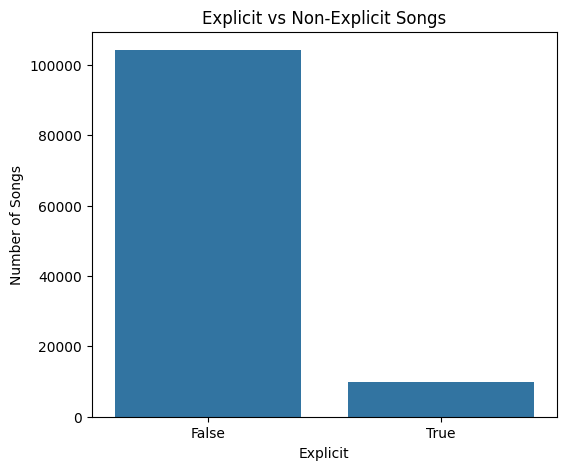

In [25]:
#explicit vs non-explicit 

plt.figure(figsize=(6, 5))

sns.countplot(data=df, x="explicit")

plt.title("Explicit vs Non-Explicit Songs")
plt.xlabel("Explicit")
plt.ylabel("Number of Songs")

plt.show()

**Observation**: Non-explicit songs are considerably more common than explicit songs in the dataset.

**Bivariate Analysis**

*In this section, we examine the relationships between different numerical features to identify possible patterns and associations.*  

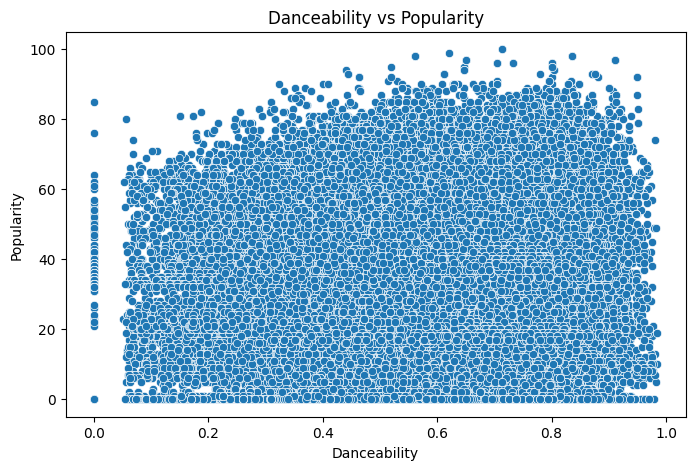

In [26]:
#Danceability vs Popularity

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="danceability",
    y="popularity"
)

plt.title("Danceability vs Popularity")
plt.xlabel("Danceability")
plt.ylabel("Popularity")

plt.show()

**Observation:** The points are widely scattered across different popularity levels. This suggests that danceability alone does not have a strong relationship with song popularity.

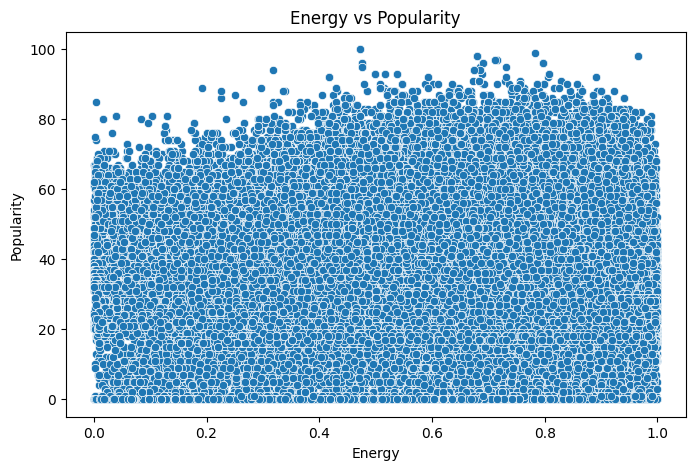

In [27]:
#Energy vs Popularity

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="energy",
    y="popularity"
)

plt.title("Energy vs Popularity")
plt.xlabel("Energy")
plt.ylabel("Popularity")

plt.show()

**Observation**: Popularity values are distributed across different energy levels. This suggests that energy alone does not strongly determine the popularity of a song.

## Correlation Analysis

Correlation analysis is used to understand the relationships between numerical features in the dataset. A correlation value ranges from -1 to +1, where values closer to +1 indicate a positive relationship, values closer to -1 indicate a negative relationship, and values near 0 indicate a weak relationship.

In [28]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min
Unnamed: 0,1.000000,0.032142,-0.032743,0.003444,-0.055994,-0.005520,-0.027307,0.005107,-0.084952,0.076840,-0.070286,0.033639,0.053111,-0.025824,-0.021115,-0.032743
popularity,0.032142,1.000000,-0.007101,0.035448,0.001056,-0.003853,0.050423,-0.013931,-0.044927,-0.025472,-0.095139,-0.005387,-0.040534,0.013205,0.031073,-0.007101
duration_ms,-0.032743,-0.007101,1.000000,-0.073426,0.058523,0.008114,-0.003470,-0.035556,-0.062600,-0.103788,0.124371,0.010321,-0.154479,0.024346,0.018225,1.000000
danceability,0.003444,0.035448,-0.073426,1.000000,0.134325,0.036469,0.259077,-0.069219,0.108626,-0.171533,-0.185606,-0.131617,0.477341,-0.050450,0.207218,-0.073426
energy,-0.055994,0.001056,0.058523,0.134325,1.000000,0.048006,0.761690,-0.078362,0.142509,-0.733906,-0.181879,0.184796,0.258934,0.247851,0.187126,0.058523
key,-0.005520,-0.003853,0.008114,0.036469,0.048006,1.000000,0.038590,-0.135916,0.020418,-0.040937,-0.006823,-0.001600,0.034103,0.010917,0.015065,0.008114
loudness,-0.027307,0.050423,-0.003470,0.259077,0.761690,0.038590,1.000000,-0.041764,0.060826,-0.589803,-0.433477,0.076899,0.279848,0.212446,0.191992,-0.003470
mode,0.005107,-0.013931,-0.035556,-0.069219,-0.078362,-0.135916,-0.041764,1.000000,-0.046532,0.095553,-0.049955,0.014012,0.021953,0.000566,-0.024092,-0.035556
speechiness,-0.084952,-0.044927,-0.062600,0.108626,0.142509,0.020418,0.060826,-0.046532,1.000000,-0.002186,-0.089616,0.205219,0.036635,0.017273,-0.000011,-0.062600
acousticness,0.076840,-0.025472,-0.103788,-0.171533,-0.733906,-0.040937,-0.589803,0.095553,-0.002186,1.000000,0.104027,-0.020700,-0.107070,-0.208224,-0.176138,-0.103788


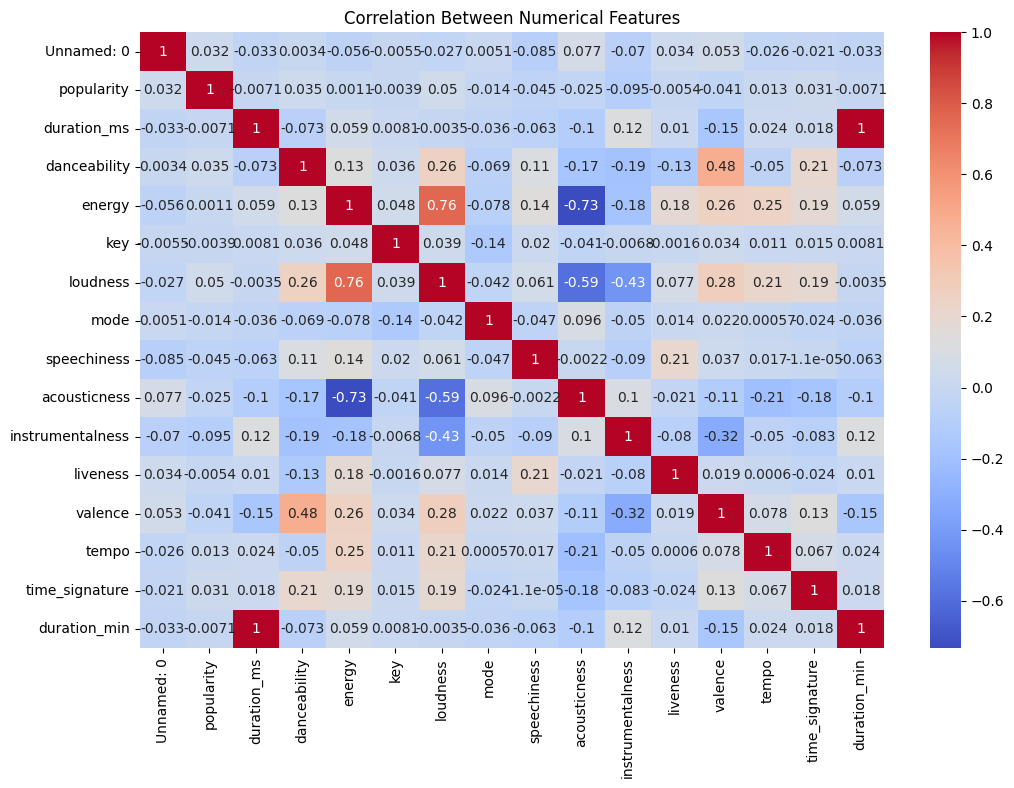

In [29]:
plt.figure(figsize=(12, 8))

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Between Numerical Features")

plt.show()

In [30]:
popularity_corr = correlation["popularity"].sort_values(ascending=False)

popularity_corr

popularity          1.000000
loudness            0.050423
danceability        0.035448
Unnamed: 0          0.032142
time_signature      0.031073
tempo               0.013205
energy              0.001056
key                -0.003853
liveness           -0.005387
duration_ms        -0.007101
duration_min       -0.007101
mode               -0.013931
acousticness       -0.025472
valence            -0.040534
speechiness        -0.044927
instrumentalness   -0.095139
Name: popularity, dtype: float64

**Observation:**

The correlation analysis shows that none of the numerical audio features has a strong correlation with popularity. Loudness has the highest positive correlation with popularity at approximately 0.05, while instrumentalness has the strongest negative correlation at approximately -0.10. Overall, the low correlation values suggest that individual audio features alone do not strongly explain song popularity.

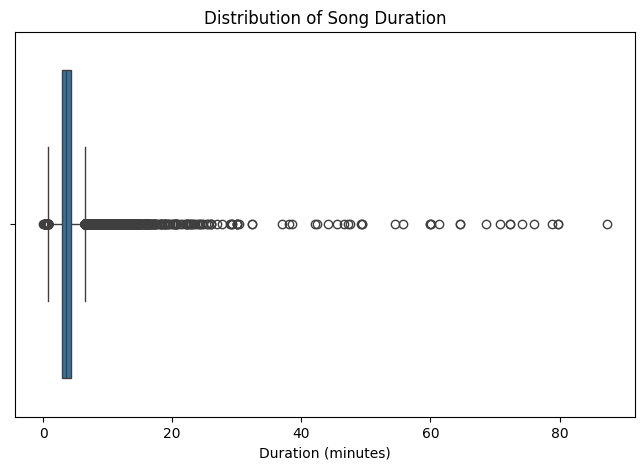

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="duration_min")

plt.title("Distribution of Song Duration")
plt.xlabel("Duration (minutes)")

plt.show()

**Observation:**

The boxplot shows that most songs have relatively short durations, while a small number of tracks have unusually high durations. These extreme values can be considered potential outliers and may represent unusually long tracks.

## Genre Analysis

In this section, we analyse the distribution of songs across different genres and compare their average popularity to identify differences between genres.

In [32]:
genre_group = df.groupby("track_genre")

genre_popularity = genre_group["popularity"].mean()

genre_popularity = genre_popularity.sort_values(ascending=False)

genre_popularity.head(10)

track_genre
pop-film     59.283
k-pop        56.896
chill        53.651
sad          52.379
grunge       49.594
indian       49.539
anime        48.772
emo          48.128
sertanejo    47.866
pop          47.576
Name: popularity, dtype: float64

## Distribution of Tracks Across Genres

This analysis shows which genres have the highest number of tracks in the dataset.

In [33]:
genre_counts = df["track_genre"].value_counts().head(10)

genre_counts

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64

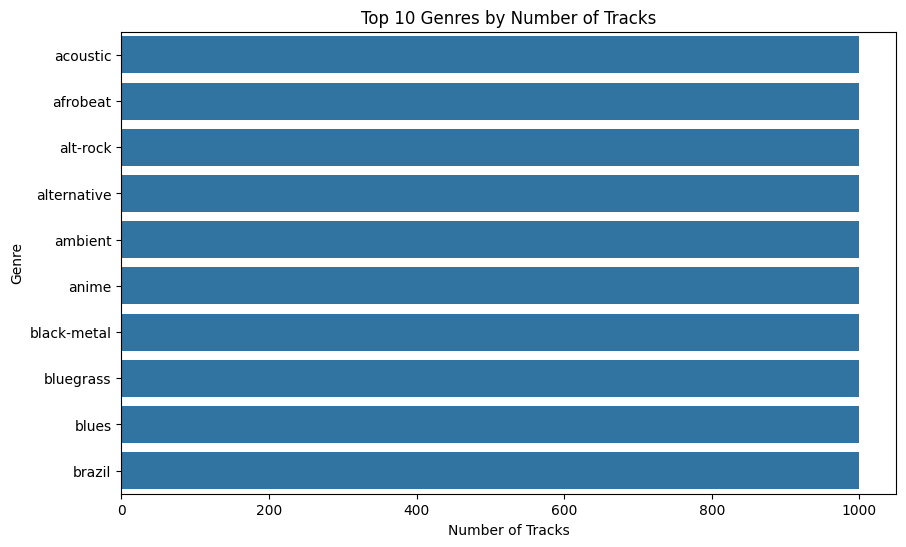

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Top 10 Genres by Number of Tracks")
plt.xlabel("Number of Tracks")
plt.ylabel("Genre")

plt.show()

Observation: The top 10 genres shown in the dataset contain approximately 1,000 tracks each. This indicates that the dataset is relatively balanced in terms of the number of tracks per genre, rather than having some genres heavily overrepresented.

## Average Popularity by Genre

This analysis compares the average popularity of songs across different genres to identify whether some genres have higher average popularity than others.

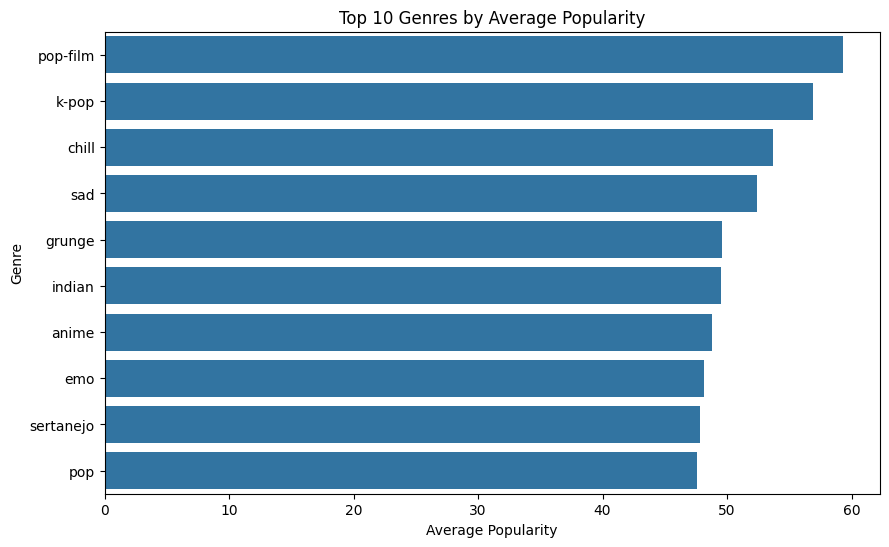

In [35]:
 top_genres = genre_popularity.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")

plt.show()

Observation: The average popularity varies across genres. Among the top 10 genres, pop-film has the highest average popularity, followed by k-pop and chill. The average popularity of these genres is around 48–59, showing noticeable differences in popularity across genres.

## Key Findings and Insights

Based on the exploratory analysis, the following key insights were identified:

1. Most songs have moderate popularity, with the majority of tracks having popularity scores between approximately 0 and 60.

2. Danceability values are generally moderate to high, with an average danceability of approximately 0.57.

3. Most songs have moderate to high energy levels, with an average energy of approximately 0.64.

4. Most songs have a duration of around 2–5 minutes, while a small number of unusually long tracks appear as potential outliers.

5. The dataset contains a large variety of genres, with approximately 1,000 tracks represented for each genre, making the genre distribution relatively balanced.

6. Non-explicit songs are considerably more common than explicit songs in the dataset.

7. Danceability and energy show no strong relationship with popularity. The correlation analysis also shows that none of the numerical audio features has a strong correlation with popularity.

8. Average popularity varies across genres. Among the top 10 genres by average popularity, pop-film has the highest average popularity, followed by k-pop and chill.

## Conclusion

The exploratory data analysis provided an overview of the Spotify dataset and revealed several patterns in song popularity, audio features, genres, and track characteristics. Most songs have moderate popularity, moderate-to-high energy and danceability, and durations of around 2–5 minutes. The analysis also identified potential outliers in song duration and showed that popularity varies across genres. Overall, the EDA helped us understand the structure and characteristics of the dataset and identify relationships between different Spotify features.